Matriz Fundamental – Juego de Serpientes y Escaleras (Versión con absorción al sobrepasar 20)

NERI FRIAS LUIS ENRIQUE


## Objetivo

Determinar el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras utilizando:

1. Resolución analítica mediante cadenas de Markov.
2. Simulación Monte Carlo.

En esta versión del problema se asumirá que:

 Si el jugador sobrepasa la casilla 20, automáticamente gana y pasa a la casilla 20.



# 1. Descripción del tablero

El tablero tiene 20 casillas.

- Inicio: casilla 1
- Final: casilla 20

Escaleras:
- 3 → 11
- 15 → 19

Serpientes:
- 13 → 4
- 17 → 10

Supuestos:
- El dado es justo de 6 caras.
- Si el jugador cae en una serpiente o escalera, se mueve inmediatamente.
- La casilla 20 es absorbente.
- Si el jugador se pasa de la casilla 20, gana automáticamente.



# 2. Modelado como cadena de Markov

Definimos el espacio de estados:

$$
E = \{1,2,3,\dots,20\}
$$

La casilla 20 es un estado absorbente.


In [1]:
import numpy as np
import pandas as pd

In [2]:
# Número de estados
N = 20

# Serpientes y escaleras
especiales = {
    3: 11,
    15: 19,
    13: 4,
    17: 10
}


# 3. Ecuaciones de esperanza

Sea:

$$
E_i
$$

el número esperado de tiradas necesarias para terminar el juego iniciando desde la casilla $i$.

Las ecuaciones de esperanza satisfacen:

$$
E_i = 1 + \sum_j P_{ij} E_j
$$

para todos los estados transitorios.



# 4. Construcción del sistema lineal

Construiremos el sistema:

$$
AE = b
$$

donde:

- \(E\) es el vector de esperanzas.
- \(A\) es la matriz del sistema.
- \(b\) es el vector independiente.


In [3]:
# Matriz del sistema
A = np.zeros((N, N))

# Vector independiente
b = np.zeros(N)

# Estado absorbente
A[19,19] = 1
b[19] = 0

for i in range(19):

    A[i,i] = 1
    b[i] = 1

    # Lanzamiento del dado
    for dado in range(1,7):

        j = i + 1 + dado

        # Si se pasa de 20, gana automáticamente
        if j > 20:
            j = 20

        # Aplicar serpientes y escaleras
        if j in especiales:
            j = especiales[j]

        A[i,j-1] -= 1/6

In [4]:
# Mostrar matriz A
pd.DataFrame(A)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.0,-0.166667,0.0,-0.166667,-0.166667,-0.166667,-0.166667,0.000000,0.000000,0.000000,-0.166667,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
1,0.0,1.000000,0.0,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,0.000000,0.000000,-0.166667,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
2,0.0,0.000000,1.0,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
3,0.0,0.000000,0.0,1.000000,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
4,0.0,0.000000,0.0,0.000000,1.000000,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
5,0.0,0.000000,0.0,0.000000,0.000000,1.000000,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
6,0.0,0.000000,0.0,-0.166667,0.000000,0.000000,1.000000,-0.166667,-0.166667,-0.166667,-0.166667,-0.166667,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
7,0.0,0.000000,0.0,-0.166667,0.000000,0.000000,0.000000,1.000000,-0.166667,-0.166667,-0.166667,-0.166667,0.0,-0.166667,0.0,0.000000,0.0,0.000000,0.000000,0.000000
8,0.0,0.000000,0.0,-0.166667,0.000000,0.000000,0.000000,0.000000,1.000000,-0.166667,-0.166667,-0.166667,0.0,-0.166667,0.0,0.000000,0.0,0.000000,-0.166667,0.000000
9,0.0,0.000000,0.0,-0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-0.166667,-0.166667,0.0,-0.166667,0.0,-0.166667,0.0,0.000000,-0.166667,0.000000



# 5. Resolución del sistema

Resolveremos:

$$
AE=b
$$

utilizando álgebra lineal.


In [5]:
# Resolver sistema
E = np.linalg.solve(A,b)

In [6]:
# Mostrar esperanzas
esperanzas = pd.DataFrame({
    'Estado': np.arange(1,21),
    'Esperanza': E
})

esperanzas

,Estado,Esperanza
0,1,6.898347
1,2,6.689589
2,3,6.754017
3,4,6.420102
4,5,6.133889
5,6,5.822239
6,7,5.907648
7,8,5.437043
8,9,4.803180
9,10,4.416613



# 6. Resultado analítico


In [7]:
print('Número promedio de tiradas iniciando desde la casilla 1:')
print(E[0])

Número promedio de tiradas iniciando desde la casilla 1:
6.898346651197903



# 7. Interpretación teórica

La ecuación:

$$
E_i = 1 + \sum_j P_{ij}E_j
$$

indica que:

- Siempre se utiliza una tirada adicional.
- Después de esa tirada, el proceso continúa desde un nuevo estado.

Resolver el sistema lineal permite encontrar el tiempo esperado de absorción.



# 8. Simulación Monte Carlo

Ahora verificaremos el resultado mediante simulación.


In [8]:
from random import randint
from statistics import mean

In [9]:
def jugar():

    posicion = 1
    tiradas = 0

    while posicion != 20:

        dado = randint(1,6)
        tiradas += 1

        siguiente = posicion + dado

        # Si se pasa de 20, gana
        if siguiente > 20:
            siguiente = 20

        # Aplicar serpientes y escaleras
        if siguiente in especiales:
            siguiente = especiales[siguiente]

        posicion = siguiente

    return tiradas

In [10]:
# Número de simulaciones
M = 100000

resultados = []

for _ in range(M):
    resultados.append(jugar())

promedio_simulado = mean(resultados)

print('Promedio simulado:')
print(promedio_simulado)

Promedio simulado:
6.89978



# 9. Comparación de resultados


In [11]:
print('Resultado analítico :', E[0])
print('Resultado simulado  :', promedio_simulado)

Resultado analítico : 6.898346651197903
Resultado simulado  : 6.89978



# 10. Histograma


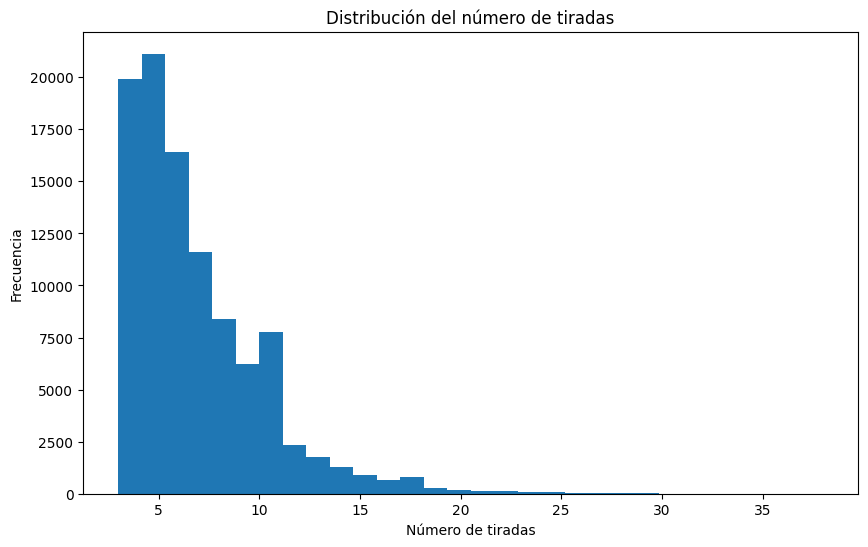

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(resultados, bins=30)

plt.xlabel('Número de tiradas')
plt.ylabel('Frecuencia')
plt.title('Distribución del número de tiradas')

plt.show()


# 11. Conclusión

El juego fue modelado mediante una cadena de Markov absorbente.

El tiempo esperado de finalización se obtuvo resolviendo el sistema lineal asociado a las ecuaciones de esperanza.

Posteriormente, el resultado fue verificado mediante simulación Monte Carlo, obteniendo valores muy cercanos al resultado teórico.

En esta versión del problema se asumió que el jugador gana automáticamente si sobrepasa la casilla 20.
